# Noiseless gain and latency response

**Scientific question.** For one fixed turbulence realization, how does a
short closed-loop residual change with integrator gain and frame latency?

The installed `gain_delay_stability_map` helper runs the shared loop engine.
Despite the historical filename, this study has `include_noise=False`: it
does not scan photon flux, read noise, or a detector-noise floor. Finite runs
illustrate a gain/delay trade, not a formal stability boundary.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.backends.native.atmosphere import (
    FrozenFlowAtmosphere,
    FrozenFlowAtmosphereConfig,
    SPECTRUM_SUBHARMONIC_V2,
    TRANSLATION_FOURIER_SUBPIXEL_V2,
)
from shwfs_ao.backends.native.shwfs import NativeShackHartmannOptics
from shwfs_ao.calibration import (
    DmActuatorProbeBasis,
    LeastSquaresReconstructor,
    calibrate_interaction_matrix,
)
from shwfs_ao.control import (
    IdentityCommandProjector,
    LeakyIntegratorController,
    LoopConfig,
    run_closed_loop,
)
from shwfs_ao.core.random import NamedRandomStreams
from shwfs_ao.detector.config import DetectorConfig
from shwfs_ao.dm import DMConfig, build_native_deformable_mirror
from shwfs_ao.wfs.shack_hartmann.geometry import build_shack_hartmann_geometry
from shwfs_ao.wfs.shack_hartmann.measurement import (
    build_detector_shack_hartmann_sensor,
)

from shwfs_ao.control import gain_delay_stability_map

In [2]:
# Fast-smoke contract (AO-REF-019): fast CI injects `FAST_SMOKE = True`
# right after this tagged cell; the committed outputs below are always
# the full study (FAST_SMOKE = False), executed by the scheduled lane.
FAST_SMOKE = False

In [3]:
SEED = 20240517
TELESCOPE_DIAMETER_M = 1.0
WFS_WAVELENGTH_M = 700e-9
GAINS = (0.2, 0.6, 1.0) if FAST_SMOKE else (0.2, 0.4, 0.6, 0.8, 1.0)
LATENCIES = (0, 1) if FAST_SMOKE else (0, 1, 2)
N_STEPS = 6 if FAST_SMOKE else 16

## Configuration

In [4]:
geometry = build_shack_hartmann_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(60, 60),
    n_lenslets_across=6,
    min_fill_fraction=0.4,
)
optics = NativeShackHartmannOptics(geometry, WFS_WAVELENGTH_M, pad_factor=8)
sensor = build_detector_shack_hartmann_sensor(
    geometry,
    optics,
    DetectorConfig(photons_per_subap_frame=2e4),
    wfs_wavelength_m=WFS_WAVELENGTH_M,
    random_streams=NamedRandomStreams(SEED),
)
mirror = build_native_deformable_mirror(
    geometry.x_m,
    geometry.y_m,
    geometry.pupil_mask,
    DMConfig(
        telescope_diameter_m=TELESCOPE_DIAMETER_M,
        n_actuators_across=7,
        coupling_width_pitch=0.35,  # Synthetic narrow Gaussian basis (~1.7% coupling).
        stroke_limit_nm=20000.0,
    ),
)
interaction = calibrate_interaction_matrix(
    DmActuatorProbeBasis(mirror),
    sensor,
    amplitude_m=25e-9,
    random_streams=NamedRandomStreams(SEED).scoped("calibration-probe"),
    include_noise=False,
)
atmosphere = FrozenFlowAtmosphere(
    FrozenFlowAtmosphereConfig(
        grid_size=geometry.pupil_shape[0],
        screen_grid_size=3 * geometry.pupil_shape[0],
        spectrum_model=SPECTRUM_SUBHARMONIC_V2,
        translation_model=TRANSLATION_FOURIER_SUBPIXEL_V2,
        normalize_rms=False,
        delta_m=geometry.pupil_geometry.pixel_spacing_xy_m[0],
        pupil_diameter_m=TELESCOPE_DIAMETER_M,
        r0_m=0.4,
        outer_scale_m=25.0,
        wind_m_per_s=(6.0, 0.0),
        root_seed=SEED,
    ),
    pupil_mask=geometry.pupil_mask,
)
base_config = LoopConfig(
    n_steps=N_STEPS, gain=0.5, leak=0.0, latency_frames=0,
    frame_rate_hz=1000.0, root_seed=SEED,
)
reconstructor = LeastSquaresReconstructor(interaction, min_valid_fraction=0.5, min_rank=1)
projector = IdentityCommandProjector(mirror.actuator_ids)


## Simulation call

In [5]:
stability = gain_delay_stability_map(
    GAINS,
    LATENCIES,
    base_config,
    random_streams=NamedRandomStreams(SEED),
    atmosphere=atmosphere,
    wfs=sensor,
    dm=mirror,
    interaction_matrix=interaction,
    reconstructor=reconstructor,
    command_projector=projector,
    include_noise=False,
)

def steady_residual(history):
    residual = np.asarray(history.post_update_residual_opd_rms_m, dtype=float)
    return float(np.mean(residual[N_STEPS // 2:]))

reference_open = np.asarray(next(iter(stability.values())).open_loop_opd_rms_m)
for history in stability.values():
    np.testing.assert_allclose(history.open_loop_opd_rms_m, reference_open, rtol=1e-12)
open_loop = float(np.mean(reference_open[N_STEPS // 2:]))
residual_map = np.array(
    [[steady_residual(stability[(g, d)]) for g in GAINS] for d in LATENCIES]
)
assert np.all(np.isfinite(residual_map)) and np.all(residual_map >= 0)


## Diagnostic table

In [6]:
table = pd.DataFrame(
    residual_map / open_loop,
    index=[f"latency {d} frame(s)" for d in LATENCIES],
    columns=[f"gain {g:.1f}" for g in GAINS],
)
print(f"open-loop RMS over final half: {open_loop * 1e9:.1f} nm "
      "(matched-window mean RMS ratios; noise disabled)")
table

open-loop RMS over final half: 117.6 nm (matched-window mean RMS ratios; noise disabled)


,gain 0.2,gain 0.4,gain 0.6,gain 0.8,gain 1.0
latency 0 frame(s),0.738826,0.722991,0.721275,0.720565,0.720116
latency 1 frame(s),0.733538,0.724776,0.721885,0.714225,0.739445
latency 2 frame(s),0.723440,0.745765,0.802188,1.064477,1.745736


## Plot

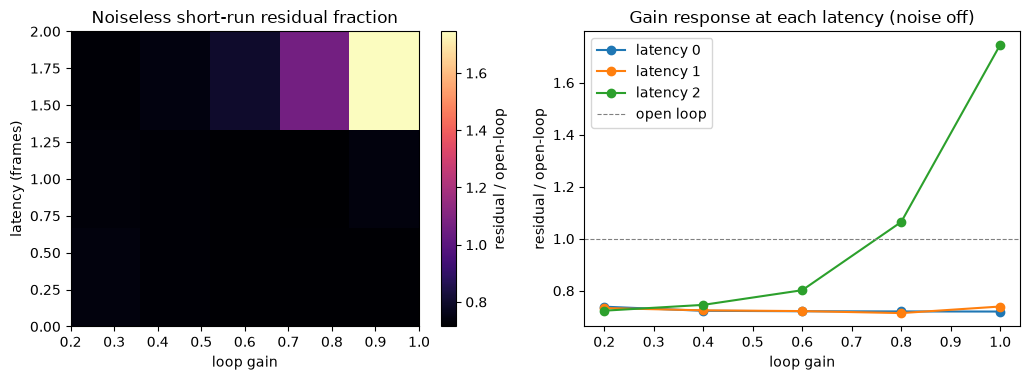

In [7]:
figure, (left, right) = plt.subplots(1, 2, figsize=(10.4, 3.9))
image = left.imshow(
    residual_map / open_loop, origin="lower", aspect="auto", cmap="magma",
    extent=[GAINS[0], GAINS[-1], LATENCIES[0], LATENCIES[-1]],
)
left.set_xlabel("loop gain")
left.set_ylabel("latency (frames)")
left.set_title("Noiseless short-run residual fraction")
figure.colorbar(image, ax=left, label="residual / open-loop")
for latency in LATENCIES:
    row = [steady_residual(stability[(g, latency)]) / open_loop for g in GAINS]
    right.plot(GAINS, row, "o-", label=f"latency {latency}")
right.axhline(1.0, color="0.5", linewidth=0.8, linestyle="--", label="open loop")
right.set_xlabel("loop gain")
right.set_ylabel("residual / open-loop")
right.set_title("Gain response at each latency (noise off)")
right.legend()
figure.tight_layout()
plt.show()

## Interpretation

The table compares mean residual RMS over the final half of each run with the
open-loop mean over that same time window. Every operating point replays the
same atmospheric disturbance, which is checked explicitly. Trends with gain
and delay therefore describe this seeded system's short-run control response.
Residual growth at high gain can indicate a poor operating point, but sixteen
frames are insufficient to locate an asymptotic stability boundary.

The mirror is a synthetic narrow Gaussian basis (`width/pitch = 0.35`, about
**1.7% neighbour coupling**); its spatial and reconstruction limitations remain
present in every row. The scan contains no photon/read-noise experiment.

## Limitations

- Detector noise is disabled in every run. A noise contribution requires a
  matched experiment that actually enables and varies it.
- One seed and short sequences can hide long-term instability or transients.
- A formal stability limit requires controller/plant analysis or longer
  trajectories, in addition to these residual summaries.
